# Hate Speech Detection in Romanized Sylheti
## A Baseline Study Using Machine Learning

**Full experimental pipeline following:**
- Hettiarachchi (2020) — Romanized Sinhala [b10]
- Eshan & Hasan (2017) — Bengali Abusive Text [b12]


**Produces:**
- Tables: CV word ngrams, TF-IDF word ngrams, CV char ngrams, TF-IDF char ngrams, summary, final
- Figures: fig1–fig10 covering accuracy, F1, ngram comparisons, heatmap, error analysis

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


## 2. File Paths

In [2]:
import os

DATASET_PATH   = '/content/drive/MyDrive/SylHate/SylHate_Annotation_2000 - Sheet1.csv'
STOPWORDS_PATH = '/content/drive/MyDrive/SylHate/sylheti_stopwords.txt'
OUTPUT_DIR     = '/content/drive/MyDrive/SylHate/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Dataset   : {DATASET_PATH}')
print(f'Stopwords : {STOPWORDS_PATH}')
print(f'Output    : {OUTPUT_DIR}')

Dataset   : /content/drive/MyDrive/SylHate/SylHate_Annotation_2000 - Sheet1.csv
Stopwords : /content/drive/MyDrive/SylHate/sylheti_stopwords.txt
Output    : /content/drive/MyDrive/SylHate/outputs


## 3. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import re
import copy
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

print('All libraries imported.')

All libraries imported.


## 4. Load Dataset

In [4]:
df = pd.read_csv(DATASET_PATH)
df = df[['Sylhaty_Romanize', 'Label']].copy()
df.columns = ['text', 'label']
df = df.dropna(subset=['text'])
df['text'] = df['text'].astype(str)

total       = len(df)
hate_count  = int(df['label'].sum())
nohate_count= total - hate_count

print(f'Total samples    : {total}')
print(f'Hate speech  (1) : {hate_count} ({hate_count/total*100:.1f}%)')
print(f'Non-hate     (0) : {nohate_count} ({nohate_count/total*100:.1f}%)')
df.head(3)

Total samples    : 7054
Hate speech  (1) : 3781 (53.6%)
Non-hate     (0) : 3273 (46.4%)


,text,label
0,furita bemar pagol,0
1,obosshoi koimu,0
2,DCr roomo j manushe camerata lagaise tare guen...,0


## 5. Figure 1 — Label Distribution (fig1.png)

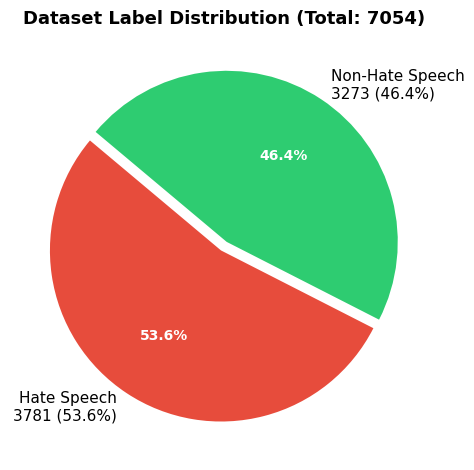

fig1.png saved.


In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
sizes   = [hate_count, nohate_count]
labels  = [f'Hate Speech\n{hate_count} ({hate_count/total*100:.1f}%)',
            f'Non-Hate Speech\n{nohate_count} ({nohate_count/total*100:.1f}%)']
colors  = ['#E74C3C', '#2ECC71']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=(0.03,0.03),
    autopct='%1.1f%%', startangle=140, textprops={'fontsize':11}
)
for at in autotexts:
    at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')
ax.set_title(f'Dataset Label Distribution (Total: {total})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig1.png saved.')

## 6. Load Stopwords

In [6]:
with open(STOPWORDS_PATH, 'r', encoding='utf-8') as f:
    SYLHETI_STOPWORDS = set(
        line.strip().lower() for line in f
        if line.strip() and not line.startswith('#')
    )
print(f'Stopwords loaded: {len(SYLHETI_STOPWORDS)} words')

Stopwords loaded: 157 words


## 7. Data Preprocessing (5 Steps)

In [7]:
def preprocess(text):
    # Step 1: Noise removal
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = text.encode('ascii','ignore').decode('ascii')
    text = re.sub(r"[^a-zA-Z0-9\s\-']", ' ', text)
    # Step 2: Special character cleaning
    text = re.sub(r'[\[\]\(\)\{\}]', ' ', text)
    text = re.sub(r'\s-\s', ' ', text)
    # Step 3: Case folding
    text = text.lower()
    # Step 4: Repeated character reduction
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # Step 5: Stopword filtering
    tokens = [t for t in text.split() if t not in SYLHETI_STOPWORDS and len(t) > 1]
    return ' '.join(tokens).strip()

df['text_raw']  = df['text']
df['text_prep'] = df['text'].apply(preprocess)

raw_vocab  = set(' '.join(df['text_raw']).split())
prep_vocab = set(' '.join(df['text_prep']).split())
raw_tokens  = len(' '.join(df['text_raw']).split())
prep_tokens = len(' '.join(df['text_prep']).split())

print(f'Vocabulary before: {len(raw_vocab):,}')
print(f'Vocabulary after : {len(prep_vocab):,}')
print(f'Tokens removed   : {raw_tokens - prep_tokens:,}')

Vocabulary before: 16,034
Vocabulary after : 13,058
Tokens removed   : 21,951


## 8. Train / Test Split (80/20 Stratified)

In [8]:
y = df['label'].values

X_raw_train,  X_raw_test,  y_train, y_test = train_test_split(
    df['text_raw'].values, y, test_size=0.2, random_state=42, stratify=y)
X_prep_train, X_prep_test, _,       _      = train_test_split(
    df['text_prep'].values, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(X_raw_train)}  |  Hate: {y_train.sum()}  Non-hate: {(y_train==0).sum()}')
print(f'Test : {len(X_raw_test)}   |  Hate: {y_test.sum()}   Non-hate: {(y_test==0).sum()}')

Train: 5643  |  Hate: 3025  Non-hate: 2618
Test : 1411   |  Hate: 756   Non-hate: 655


## 9. Vectorizer and Model Definitions

In [9]:
MAX_FEATURES = 50000
DENSE_MODELS = {'GNB'}  # GaussianNB needs dense input

def build_vec(vec_type, analyzer, ngram_range, min_df):
    if vec_type == 'count':
        return CountVectorizer(analyzer=analyzer, ngram_range=ngram_range,
                               min_df=min_df, max_features=MAX_FEATURES)
    return TfidfVectorizer(analyzer=analyzer, ngram_range=ngram_range,
                            min_df=min_df, sublinear_tf=True,
                            max_features=MAX_FEATURES)

def get_models():
    return {
        'LR'        : (LogisticRegression(max_iter=1000, random_state=42),
                       {'C':[0.1,1,10], 'solver':['lbfgs','liblinear']}),
        'SVM'       : (LinearSVC(max_iter=2000, random_state=42),
                       {'C':[0.1,1,10]}),
        'MNB(0.1)'  : (MultinomialNB(alpha=0.1), {}),
        'MNB(1)'    : (MultinomialNB(alpha=1.0),  {}),
        'MNB(10)'   : (MultinomialNB(alpha=10.0), {}),
        'RF'        : (RandomForestClassifier(random_state=42),
                       {'n_estimators':[100], 'max_depth':[None]}),
        'BNB'       : (BernoulliNB(), {'alpha':[0.1,1.0]}),
        'GNB'       : (GaussianNB(), {}),
        'DT'        : (DecisionTreeClassifier(random_state=42),
                       {'max_depth':[None,10], 'criterion':['gini','entropy']}),
        'KNN'       : (KNeighborsClassifier(), {'n_neighbors':[5]}),
    }

def fit_eval(clf, pg, X_tr, X_te, y_tr, y_te):
    clf = copy.deepcopy(clf)
    if pg:
        gs = GridSearchCV(clf, pg, cv=3, scoring='f1_weighted', n_jobs=-1)
        gs.fit(X_tr, y_tr)
        y_pred = gs.best_estimator_.predict(X_te)
    else:
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_te)
    return {
        'Acc' : round(accuracy_score(y_te, y_pred), 4),
        'Prec': round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'Rec' : round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4),
        'F1'  : round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4),
    }, y_pred

print('Helpers defined.')

Helpers defined.


## 10. Core Experiment Runner
Runs all models across a given set of configurations. Returns a results DataFrame.

In [10]:
def run_experiments(X_train, X_test, y_train, y_test,
                    vec_type, analyzer, ngram_list, min_df_list,
                    text_type='raw'):
    """
    For a fixed vectorizer type and analyzer, run all models
    across all ngram x min_df combinations.
    Returns a DataFrame with one row per (model, ngram, min_df).
    """
    models  = get_models()
    records = []

    for ngram in ngram_list:
        for min_df in min_df_list:
            vec  = build_vec(vec_type, analyzer, ngram, min_df)
            X_tr = vec.fit_transform(X_train)
            X_te = vec.transform(X_test)
            ngram_label = f'({ngram[0]},{ngram[1]})'

            for mname, (clf, pg) in models.items():
                try:
                    xtr = X_tr.toarray() if mname in DENSE_MODELS else X_tr
                    xte = X_te.toarray() if mname in DENSE_MODELS else X_te
                    res, _ = fit_eval(clf, pg, xtr, xte, y_train, y_test)
                    records.append({
                        'TextType'  : text_type,
                        'Vectorizer': vec_type.upper(),
                        'Analyzer'  : analyzer,
                        'NGram'     : ngram_label,
                        'min_df'    : min_df,
                        'Model'     : mname,
                        **res
                    })
                except Exception as e:
                    pass

    return pd.DataFrame(records)

print('run_experiments() defined.')

run_experiments() defined.


## 11. Run All Experiments
**This is the main computation cell — takes ~20-40 min on Colab CPU.**

In [11]:
WORD_NGRAMS  = [(1,1), (1,2), (1,3)]
CHAR_NGRAMS  = [(2,2), (3,3), (4,4), (5,5)]
MIN_DF_LIST  = [1, 2, 5]

all_results = []

for text_type, X_train, X_test in [
    ('raw',  X_raw_train,  X_raw_test),
    ('prep', X_prep_train, X_prep_test)
]:
    print(f'\n=== Text type: {text_type.upper()} ===')
    for vec_type in ['count', 'tfidf']:
        print(f'  Vectorizer: {vec_type.upper()}')
        print(f'    Word n-grams...')
        df_w = run_experiments(X_train, X_test, y_train, y_test,
                               vec_type, 'word', WORD_NGRAMS, MIN_DF_LIST, text_type)
        all_results.append(df_w)
        print(f'    Char n-grams...')
        df_c = run_experiments(X_train, X_test, y_train, y_test,
                               vec_type, 'char', CHAR_NGRAMS, MIN_DF_LIST, text_type)
        all_results.append(df_c)

results = pd.concat(all_results, ignore_index=True)
results.to_csv(f'{OUTPUT_DIR}/all_results.csv', index=False)
print(f'\nAll experiments done. Total rows: {len(results)}')
print('Saved to all_results.csv')


=== Text type: RAW ===
  Vectorizer: COUNT
    Word n-grams...
    Char n-grams...
  Vectorizer: TFIDF
    Word n-grams...
    Char n-grams...

=== Text type: PREP ===
  Vectorizer: COUNT
    Word n-grams...
    Char n-grams...
  Vectorizer: TFIDF
    Word n-grams...
    Char n-grams...

All experiments done. Total rows: 840
Saved to all_results.csv


## 12. Helper: Best Result per Model per Config

In [12]:
def best_per_model(df_subset):
    """For each model, pick the row with highest F1 across all min_df values."""
    return (
        df_subset
        .sort_values('F1', ascending=False)
        .groupby('Model', sort=False)
        .first()
        .reset_index()
    )

MODEL_ORDER = ['LR','SVM','MNB(0.1)','RF','BNB','MNB(1)','DT','GNB','MNB(10)','KNN']

def sort_models(df):
    df['_order'] = df['Model'].map({m:i for i,m in enumerate(MODEL_ORDER)})
    return df.sort_values('_order').drop(columns='_order').reset_index(drop=True)

print('Helpers ready.')

Helpers ready.


## 13. Table A — CountVectorizer Word N-grams (Raw vs Preprocessed)

In [13]:
# Best F1 per model per ngram under CountVectorizer word-level
tA_raw  = results[(results.Vectorizer=='COUNT') & (results.Analyzer=='word') & (results.TextType=='raw')]
tA_prep = results[(results.Vectorizer=='COUNT') & (results.Analyzer=='word') & (results.TextType=='prep')]

def ngram_pivot(df_subset, metric='F1'):
    """Pivot: rows=Model, cols=NGram, values=metric (best min_df per cell)"""
    best = df_subset.sort_values(metric, ascending=False).groupby(
        ['Model','NGram'], sort=False).first().reset_index()
    pivot = best.pivot(index='Model', columns='NGram', values=metric)
    # reorder columns
    cols = ['(1,1)','(1,2)','(1,3)']
    pivot = pivot[[c for c in cols if c in pivot.columns]]
    pivot.columns = ['Unigram','Bigram','Trigram']
    return pivot

print('=== Table A: CountVectorizer Word N-grams — Best F1 per Model per N-gram ===')
print('--- RAW TEXT ---')
pA_raw = ngram_pivot(tA_raw)
print(pA_raw.round(4).to_string())
print('--- PREPROCESSED TEXT ---')
pA_prep = ngram_pivot(tA_prep)
print(pA_prep.round(4).to_string())
print()

# Save combined
pA_raw.round(4).to_csv(f'{OUTPUT_DIR}/tableA_CV_word_raw.csv')
pA_prep.round(4).to_csv(f'{OUTPUT_DIR}/tableA_CV_word_prep.csv')
print('Table A saved.')

=== Table A: CountVectorizer Word N-grams — Best F1 per Model per N-gram ===
--- RAW TEXT ---
          Unigram  Bigram  Trigram
Model                             
BNB        0.7911  0.7916   0.7923
DT         0.7211  0.7381   0.7331
GNB        0.7566  0.7263   0.7256
KNN        0.6670  0.6385   0.6384
LR         0.8046  0.7975   0.7919
MNB(0.1)   0.7906  0.7865   0.7872
MNB(1)     0.8070  0.7937   0.7969
MNB(10)    0.7787  0.7773   0.7775
RF         0.7742  0.7678   0.7758
SVM        0.8095  0.7975   0.7996
--- PREPROCESSED TEXT ---
          Unigram  Bigram  Trigram
Model                             
BNB        0.7982  0.8095   0.8124
DT         0.7636  0.7678   0.7657
GNB        0.7484  0.7331   0.7329
KNN        0.6770  0.6950   0.6950
LR         0.8039  0.8025   0.8039
MNB(0.1)   0.7819  0.7828   0.7843
MNB(1)     0.7925  0.7830   0.7830
MNB(10)    0.7425  0.7495   0.7503
RF         0.7996  0.7963   0.7969
SVM        0.8032  0.8025   0.8031

Table A saved.


## 14. Table B — TF-IDF Word N-grams (Raw vs Preprocessed)

In [14]:
tB_raw  = results[(results.Vectorizer=='TFIDF') & (results.Analyzer=='word') & (results.TextType=='raw')]
tB_prep = results[(results.Vectorizer=='TFIDF') & (results.Analyzer=='word') & (results.TextType=='prep')]

print('=== Table B: TF-IDF Word N-grams — Best F1 per Model per N-gram ===')
print('--- RAW TEXT ---')
pB_raw = ngram_pivot(tB_raw)
print(pB_raw.round(4).to_string())
print('--- PREPROCESSED TEXT ---')
pB_prep = ngram_pivot(tB_prep)
print(pB_prep.round(4).to_string())

pB_raw.round(4).to_csv(f'{OUTPUT_DIR}/tableB_TFIDF_word_raw.csv')
pB_prep.round(4).to_csv(f'{OUTPUT_DIR}/tableB_TFIDF_word_prep.csv')
print('Table B saved.')

=== Table B: TF-IDF Word N-grams — Best F1 per Model per N-gram ===
--- RAW TEXT ---
          Unigram  Bigram  Trigram
Model                             
BNB        0.7911  0.7916   0.7923
DT         0.7196  0.7174   0.7147
GNB        0.7549  0.7344   0.7364
KNN        0.7563  0.7406   0.5740
LR         0.8080  0.7935   0.7907
MNB(0.1)   0.7978  0.7916   0.7945
MNB(1)     0.7996  0.7963   0.7942
MNB(10)    0.7563  0.7529   0.7545
RF         0.7727  0.7706   0.7607
SVM        0.7908  0.7964   0.7915
--- PREPROCESSED TEXT ---
          Unigram  Bigram  Trigram
Model                             
BNB        0.7982  0.8095   0.8124
DT         0.7493  0.7628   0.7521
GNB        0.7564  0.7359   0.7349
KNN        0.5960  0.5839   0.6121
LR         0.7932  0.7960   0.7967
MNB(0.1)   0.7876  0.7830   0.7857
MNB(1)     0.7862  0.7753   0.7770
MNB(10)    0.7139  0.7198   0.7198
RF         0.7897  0.7919   0.7939
SVM        0.7968  0.7974   0.7974
Table B saved.


## 15. Table C — CountVectorizer Character N-grams

In [15]:
def char_pivot(df_subset, metric='F1'):
    best = df_subset.sort_values(metric, ascending=False).groupby(
        ['Model','NGram'], sort=False).first().reset_index()
    pivot = best.pivot(index='Model', columns='NGram', values=metric)
    cols = ['(2,2)','(3,3)','(4,4)','(5,5)']
    pivot = pivot[[c for c in cols if c in pivot.columns]]
    pivot.columns = [f'Char-{c[1]}' for c in pivot.columns]
    return pivot

tC_raw  = results[(results.Vectorizer=='COUNT') & (results.Analyzer=='char') & (results.TextType=='raw')]
tC_prep = results[(results.Vectorizer=='COUNT') & (results.Analyzer=='char') & (results.TextType=='prep')]

print('=== Table C: CountVectorizer Char N-grams — Best F1 per Model per N ===')
print('--- RAW ---')
pC_raw = char_pivot(tC_raw)
print(pC_raw.round(4).to_string())
print('--- PREPROCESSED ---')
pC_prep = char_pivot(tC_prep)
print(pC_prep.round(4).to_string())

pC_raw.round(4).to_csv(f'{OUTPUT_DIR}/tableC_CV_char_raw.csv')
pC_prep.round(4).to_csv(f'{OUTPUT_DIR}/tableC_CV_char_prep.csv')
print('Table C saved.')

=== Table C: CountVectorizer Char N-grams — Best F1 per Model per N ===
--- RAW ---
          Char-2  Char-3  Char-4  Char-5
Model                                   
BNB       0.6902  0.7746  0.7940  0.8136
DT        0.6746  0.7187  0.7753  0.7833
GNB       0.5355  0.6460  0.7741  0.7807
KNN       0.6506  0.6950  0.5819  0.5418
LR        0.7612  0.8073  0.8201  0.8273
MNB(0.1)  0.7291  0.7960  0.8130  0.8143
MNB(1)    0.7290  0.8006  0.8102  0.8080
MNB(10)   0.7206  0.7885  0.8056  0.8024
RF        0.7617  0.8068  0.8106  0.8195
SVM       0.7555  0.7924  0.8137  0.8089
--- PREPROCESSED ---
          Char-2  Char-3  Char-4  Char-5
Model                                   
BNB       0.7380  0.8031  0.8214  0.8089
DT        0.6955  0.7392  0.7738  0.7811
GNB       0.5551  0.6401  0.7621  0.7610
KNN       0.7043  0.6806  0.6406  0.5970
LR        0.7501  0.8074  0.8358  0.8244
MNB(0.1)  0.7234  0.7885  0.8095  0.7991
MNB(1)    0.7205  0.7882  0.8046  0.7935
MNB(10)   0.7155  0.7734  0.7867  

## 16. Table D — TF-IDF Character N-grams

In [16]:
tD_raw  = results[(results.Vectorizer=='TFIDF') & (results.Analyzer=='char') & (results.TextType=='raw')]
tD_prep = results[(results.Vectorizer=='TFIDF') & (results.Analyzer=='char') & (results.TextType=='prep')]

print('=== Table D: TF-IDF Char N-grams — Best F1 per Model per N ===')
print('--- RAW ---')
pD_raw = char_pivot(tD_raw)
print(pD_raw.round(4).to_string())
print('--- PREPROCESSED ---')
pD_prep = char_pivot(tD_prep)
print(pD_prep.round(4).to_string())

pD_raw.round(4).to_csv(f'{OUTPUT_DIR}/tableD_TFIDF_char_raw.csv')
pD_prep.round(4).to_csv(f'{OUTPUT_DIR}/tableD_TFIDF_char_prep.csv')
print('Table D saved.')

=== Table D: TF-IDF Char N-grams — Best F1 per Model per N ===
--- RAW ---
          Char-2  Char-3  Char-4  Char-5
Model                                   
BNB       0.6902  0.7746  0.7940  0.8136
DT        0.6687  0.6938  0.7770  0.7650
GNB       0.5346  0.7056  0.7742  0.7784
KNN       0.7100  0.7522  0.3197  0.3479
LR        0.7648  0.8109  0.8201  0.8208
MNB(0.1)  0.7075  0.7955  0.8133  0.8166
MNB(1)    0.7140  0.7895  0.8052  0.8027
MNB(10)   0.6397  0.7004  0.7318  0.7375
RF        0.7379  0.7889  0.8142  0.8202
SVM       0.7663  0.8123  0.8201  0.8227
--- PREPROCESSED ---
          Char-2  Char-3  Char-4  Char-5
Model                                   
BNB       0.7380  0.8031  0.8214  0.8089
DT        0.6803  0.7231  0.7624  0.7691
GNB       0.5680  0.6947  0.7622  0.7735
KNN       0.5729  0.3795  0.3813  0.3866
LR        0.7536  0.8124  0.8273  0.8286
MNB(0.1)  0.7159  0.7839  0.8023  0.7946
MNB(1)    0.7126  0.7873  0.7921  0.7899
MNB(10)   0.6560  0.6871  0.7087  0.7254
RF

## 17. Table E — Summary: Best per Model under CV vs TF-IDF (Preprocessed)

In [17]:
# Best F1 per model under CountVectorizer (any ngram, any min_df)
best_cv   = results[(results.Vectorizer=='COUNT') & (results.TextType=='prep')]\
             .sort_values('F1',ascending=False)\
             .groupby('Model').first().reset_index()[['Model','Acc','Prec','Rec','F1']]
best_cv.columns = ['Model','CV_Acc','CV_Prec','CV_Rec','CV_F1']

best_tfidf = results[(results.Vectorizer=='TFIDF') & (results.TextType=='prep')]\
              .sort_values('F1',ascending=False)\
              .groupby('Model').first().reset_index()[['Model','Acc','Prec','Rec','F1']]
best_tfidf.columns = ['Model','TF_Acc','TF_Prec','TF_Rec','TF_F1']

tableE = best_cv.merge(best_tfidf, on='Model')
tableE['Best_Vec'] = tableE.apply(
    lambda r: 'TF-IDF' if r['TF_F1'] >= r['CV_F1'] else 'COUNT', axis=1)
tableE = tableE.sort_values('TF_F1', ascending=False)

print('=== Table E: Summary CV vs TF-IDF — Preprocessed Text ===')
print(tableE.round(4).to_string(index=False))
tableE.round(4).to_csv(f'{OUTPUT_DIR}/tableE_summary_CV_vs_TFIDF.csv', index=False)
print('Table E saved.')

=== Table E: Summary CV vs TF-IDF — Preprocessed Text ===
   Model  CV_Acc  CV_Prec  CV_Rec  CV_F1  TF_Acc  TF_Prec  TF_Rec  TF_F1 Best_Vec
      LR  0.8356   0.8379  0.8356 0.8358  0.8285   0.8289  0.8285 0.8286    COUNT
     SVM  0.8179   0.8192  0.8179 0.8181  0.8271   0.8280  0.8271 0.8272   TF-IDF
     BNB  0.8214   0.8215  0.8214 0.8214  0.8214   0.8215  0.8214 0.8214   TF-IDF
      RF  0.8150   0.8172  0.8150 0.8153  0.8179   0.8201  0.8179 0.8181   TF-IDF
MNB(0.1)  0.8101   0.8103  0.8101 0.8095  0.8030   0.8033  0.8030 0.8023    COUNT
  MNB(1)  0.8051   0.8053  0.8051 0.8046  0.7938   0.7963  0.7938 0.7921    COUNT
     GNB  0.7619   0.7674  0.7619 0.7621  0.7732   0.7749  0.7732 0.7735   TF-IDF
      DT  0.7810   0.7813  0.7810 0.7811  0.7690   0.7692  0.7690 0.7691    COUNT
 MNB(10)  0.7895   0.7956  0.7895 0.7867  0.7399   0.7770  0.7399 0.7254    COUNT
     KNN  0.7045   0.7042  0.7045 0.7043  0.6258   0.6709  0.6258 0.6121    COUNT
Table E saved.


## 18. Table F — Final Results: Best Config per Model, Raw vs Preprocessed
*(This is the main paper Table II)*

In [18]:
best_raw  = results[results.TextType=='raw']\
             .sort_values('F1',ascending=False)\
             .groupby('Model').first().reset_index()[['Model','Acc','Prec','Rec','F1']]
best_raw.columns = ['Model','Raw_Acc','Raw_Prec','Raw_Rec','Raw_F1']

best_prep = results[results.TextType=='prep']\
             .sort_values('F1',ascending=False)\
             .groupby('Model').first().reset_index()[['Model','Acc','Prec','Rec','F1']]
best_prep.columns = ['Model','Prep_Acc','Prep_Prec','Prep_Rec','Prep_F1']

tableF = best_raw.merge(best_prep, on='Model')
tableF['Delta_F1'] = (tableF['Prep_F1'] - tableF['Raw_F1']).round(4)
tableF = tableF.sort_values('Prep_F1', ascending=False).reset_index(drop=True)

print('=== Table F: Final Results — Raw vs Preprocessed (Paper Table II) ===')
print(f'{"Model":<12} | {"Raw":^30} | {"Prep":^30} | Delta')
print(f'{"":12} | {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} | {"Acc":>6} {"Prec":>6} {"Rec":>6} {"F1":>6} | F1')
print('-'*85)
for _,r in tableF.iterrows():
    print(f'{r.Model:<12} | {r.Raw_Acc:>6.4f} {r.Raw_Prec:>6.4f} {r.Raw_Rec:>6.4f} {r.Raw_F1:>6.4f} | '
          f'{r.Prep_Acc:>6.4f} {r.Prep_Prec:>6.4f} {r.Prep_Rec:>6.4f} {r.Prep_F1:>6.4f} | {r.Delta_F1:>+.4f}')
tableF.round(4).to_csv(f'{OUTPUT_DIR}/tableF_final_results.csv', index=False)
print('\nTable F saved.')

=== Table F: Final Results — Raw vs Preprocessed (Paper Table II) ===
Model        |              Raw               |              Prep              | Delta
             |    Acc   Prec    Rec     F1 |    Acc   Prec    Rec     F1 | F1
-------------------------------------------------------------------------------------
LR           | 0.8271 0.8286 0.8271 0.8273 | 0.8356 0.8379 0.8356 0.8358 | +0.0085
SVM          | 0.8228 0.8227 0.8228 0.8227 | 0.8271 0.8280 0.8271 0.8272 | +0.0045
BNB          | 0.8143 0.8150 0.8143 0.8136 | 0.8214 0.8215 0.8214 0.8214 | +0.0078
RF           | 0.8200 0.8222 0.8200 0.8202 | 0.8179 0.8201 0.8179 0.8181 | -0.0021
MNB(0.1)     | 0.8172 0.8176 0.8172 0.8166 | 0.8101 0.8103 0.8101 0.8095 | -0.0071
MNB(1)       | 0.8108 0.8110 0.8108 0.8102 | 0.8051 0.8053 0.8051 0.8046 | -0.0056
MNB(10)      | 0.8072 0.8102 0.8072 0.8056 | 0.7895 0.7956 0.7895 0.7867 | -0.0189
DT           | 0.7838 0.7838 0.7838 0.7833 | 0.7810 0.7813 0.7810 0.7811 | -0.0022
GNB          | 

## 19. Figure 2 — Accuracy Comparison: Raw vs Preprocessed (fig2.png)

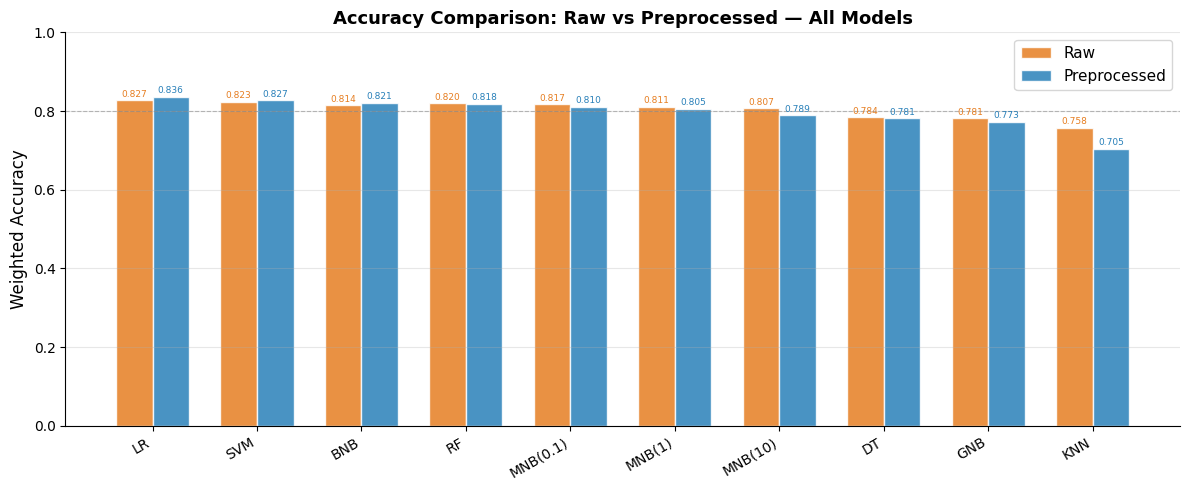

fig2.png saved.


In [19]:
model_order_f = tableF['Model'].tolist()
x = np.arange(len(model_order_f))
w = 0.35
fig, ax = plt.subplots(figsize=(12,5))
b1 = ax.bar(x-w/2, tableF['Raw_Acc'],  w, label='Raw',          color='#E67E22', alpha=0.85, edgecolor='white')
b2 = ax.bar(x+w/2, tableF['Prep_Acc'], w, label='Preprocessed', color='#2980B9', alpha=0.85, edgecolor='white')
for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5, color='#E67E22')
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5, color='#2980B9')
ax.set_xticks(x); ax.set_xticklabels(model_order_f, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Weighted Accuracy', fontsize=12)
ax.set_title('Accuracy Comparison: Raw vs Preprocessed — All Models', fontsize=13, fontweight='bold')
ax.set_ylim(0,1.0); ax.axhline(0.8, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig2.png saved.')

## 20. Figure 3 — F1-Score Comparison: Raw vs Preprocessed (fig3.png)

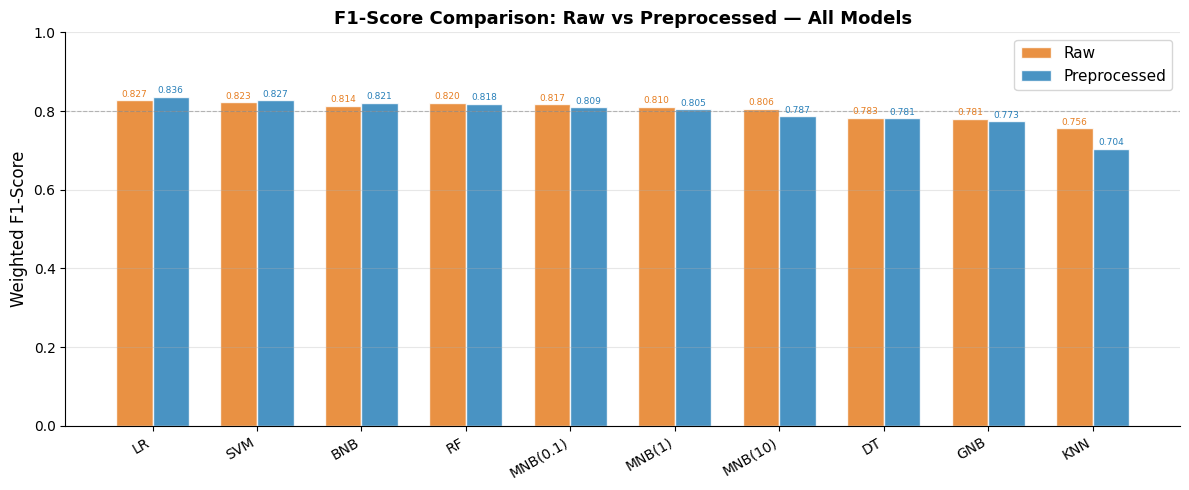

fig3.png saved.


In [20]:
fig, ax = plt.subplots(figsize=(12,5))
b1 = ax.bar(x-w/2, tableF['Raw_F1'],  w, label='Raw',          color='#E67E22', alpha=0.85, edgecolor='white')
b2 = ax.bar(x+w/2, tableF['Prep_F1'], w, label='Preprocessed', color='#2980B9', alpha=0.85, edgecolor='white')
for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5, color='#E67E22')
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=6.5, color='#2980B9')
ax.set_xticks(x); ax.set_xticklabels(model_order_f, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Weighted F1-Score', fontsize=12)
ax.set_title('F1-Score Comparison: Raw vs Preprocessed — All Models', fontsize=13, fontweight='bold')
ax.set_ylim(0,1.0); ax.axhline(0.8, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig3.png saved.')

## 21. Figure 4 — CountVectorizer Word N-gram Accuracy
*(Grouped bar chart style matching Eshan & Hasan 2017)*
- X-axis: N-gram configuration (Unigram, Bigram, Trigram)
- Y-axis: Accuracy (%)
- One bar group per n-gram, one bar per model
- Hatching patterns to distinguish models (no solid colors)

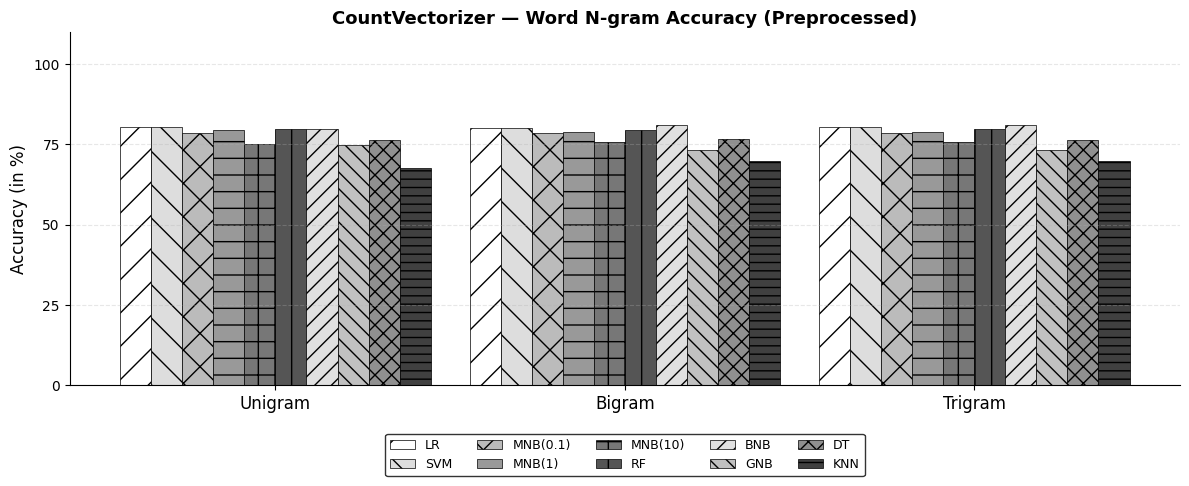

fig4.png saved.


In [21]:
# ── Figure 4: CV Word N-gram Grouped Bar Chart (Eshan & Hasan style) ──────
cv_word_prep = results[
    (results.Vectorizer=='COUNT') &
    (results.Analyzer=='word') &
    (results.TextType=='prep')
]

# Best accuracy per model per ngram (best min_df per cell)
cv_best = (
    cv_word_prep
    .sort_values('Acc', ascending=False)
    .groupby(['Model','NGram'], sort=False)
    .first()
    .reset_index()
)

ngram_keys   = ['(1,1)', '(1,2)', '(1,3)']
ngram_labels = ['Unigram', 'Bigram', 'Trigram']
model_list   = ['LR','SVM','MNB(0.1)','MNB(1)','MNB(10)','RF','BNB','GNB','DT','KNN']

# Hatching patterns — one per model, matching Eshan & Hasan style
hatches = ['/', '\\', 'x', '-', '+', '|', '//', '\\\\', 'xx', '--']
# Grayscale colors (light to dark) — matching their black/white style
grays   = ['#FFFFFF','#DDDDDD','#BBBBBB','#999999','#777777',
           '#555555','#E0E0E0','#C0C0C0','#909090','#404040']

n_models = len(model_list)
n_groups = len(ngram_keys)
bar_w    = 0.08          # width of each bar
group_w  = bar_w * n_models + 0.1  # total group width
group_centres = np.arange(n_groups) * group_w

fig, ax = plt.subplots(figsize=(12, 5))

for i, mname in enumerate(model_list):
    accs = []
    for nk in ngram_keys:
        row = cv_best[(cv_best.Model==mname) & (cv_best.NGram==nk)]
        accs.append(row['Acc'].values[0]*100 if len(row)>0 else 0)

    x_pos = group_centres + (i - n_models/2 + 0.5) * bar_w
    ax.bar(
        x_pos, accs, bar_w,
        label=mname,
        color=grays[i],
        hatch=hatches[i],
        edgecolor='black',
        linewidth=0.5
    )

ax.set_xticks(group_centres)
ax.set_xticklabels(ngram_labels, fontsize=12)
ax.set_ylabel('Accuracy (in %)', fontsize=12)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_title('CountVectorizer — Word N-gram Accuracy (Preprocessed)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend below chart — matching Eshan & Hasan layout
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    fontsize=9,
    frameon=True,
    edgecolor='black'
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig4.png saved.')

## 22. Figure 5 — TF-IDF Word N-gram Accuracy
*(Grouped bar chart style matching Eshan & Hasan 2017)*

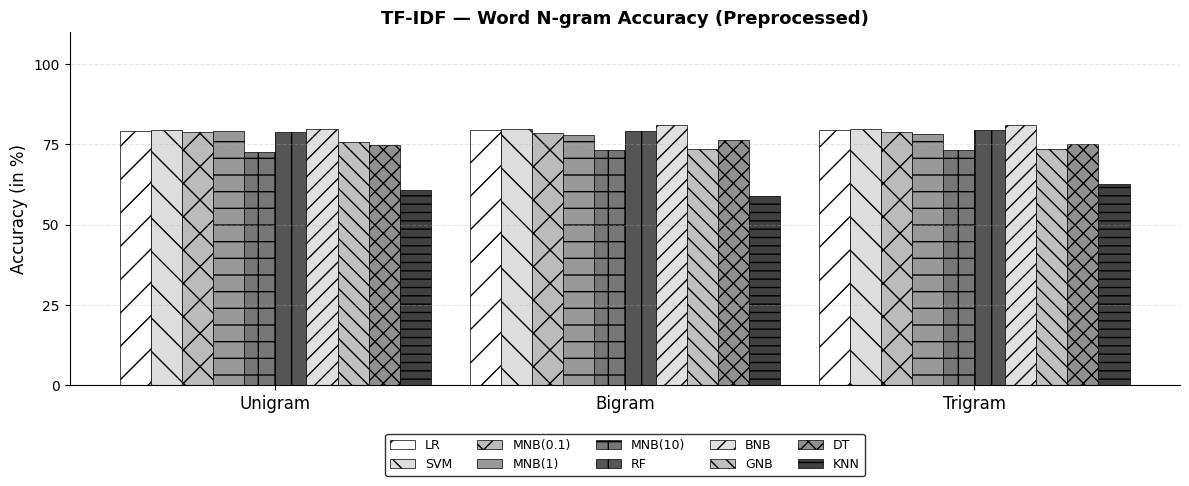

fig5.png saved.


In [22]:
# ── Figure 5: TF-IDF Word N-gram Grouped Bar Chart (Eshan & Hasan style) ──
tfidf_word_prep = results[
    (results.Vectorizer=='TFIDF') &
    (results.Analyzer=='word') &
    (results.TextType=='prep')
]

tf_best = (
    tfidf_word_prep
    .sort_values('Acc', ascending=False)
    .groupby(['Model','NGram'], sort=False)
    .first()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for i, mname in enumerate(model_list):
    accs = []
    for nk in ngram_keys:
        row = tf_best[(tf_best.Model==mname) & (tf_best.NGram==nk)]
        accs.append(row['Acc'].values[0]*100 if len(row)>0 else 0)

    x_pos = group_centres + (i - n_models/2 + 0.5) * bar_w
    ax.bar(
        x_pos, accs, bar_w,
        label=mname,
        color=grays[i],
        hatch=hatches[i],
        edgecolor='black',
        linewidth=0.5
    )

ax.set_xticks(group_centres)
ax.set_xticklabels(ngram_labels, fontsize=12)
ax.set_ylabel('Accuracy (in %)', fontsize=12)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_title('TF-IDF — Word N-gram Accuracy (Preprocessed)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    fontsize=9,
    frameon=True,
    edgecolor='black'
)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig5.png saved.')

## 23. Figure 6 — Character N-gram Accuracy: CV vs TF-IDF
*(Grouped bar chart style matching Eshan & Hasan 2017)*

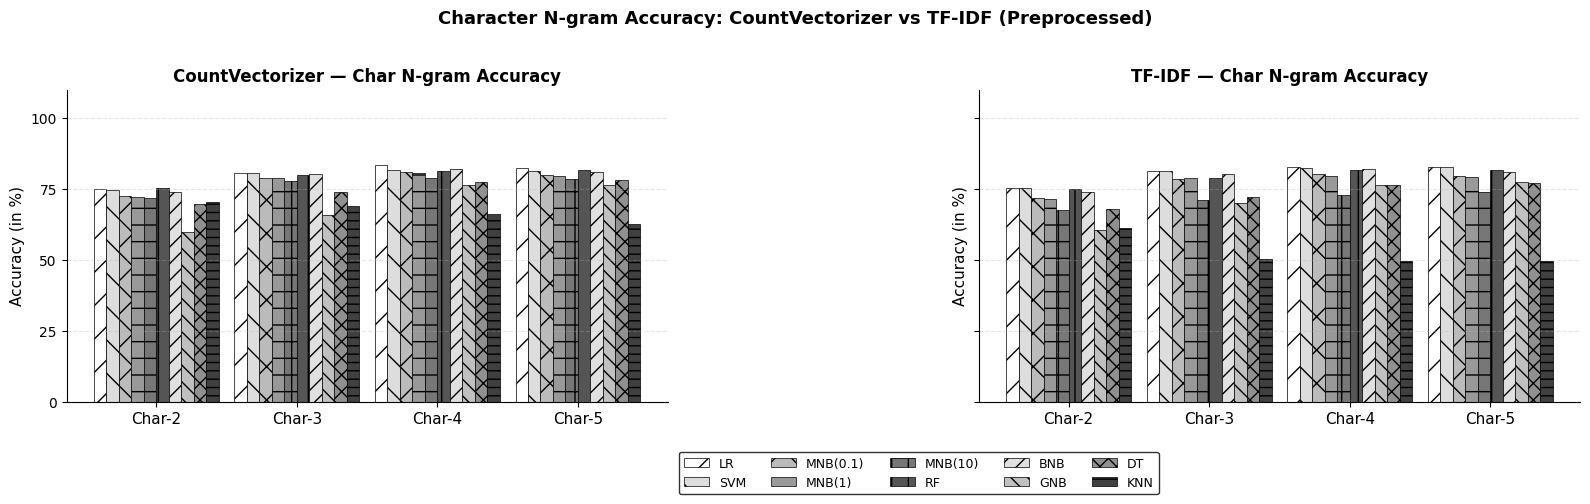

fig6.png saved.


In [23]:
# ── Figure 6: Char N-gram Grouped Bar Chart — CV vs TF-IDF ────────────────
char_keys   = ['(2,2)', '(3,3)', '(4,4)', '(5,5)']
char_labels = ['Char-2', 'Char-3', 'Char-4', 'Char-5']

n_char_groups = len(char_keys)
char_group_centres = np.arange(n_char_groups) * group_w

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax_idx, (vec, title) in enumerate([
    ('COUNT', 'CountVectorizer — Char N-gram Accuracy'),
    ('TFIDF', 'TF-IDF — Char N-gram Accuracy')
]):
    ax = axes[ax_idx]
    char_subset = results[
        (results.Vectorizer==vec) &
        (results.Analyzer=='char') &
        (results.TextType=='prep')
    ]
    char_best_sub = (
        char_subset
        .sort_values('Acc', ascending=False)
        .groupby(['Model','NGram'], sort=False)
        .first()
        .reset_index()
    )

    for i, mname in enumerate(model_list):
        accs = []
        for ck in char_keys:
            row = char_best_sub[
                (char_best_sub.Model==mname) & (char_best_sub.NGram==ck)
            ]
            accs.append(row['Acc'].values[0]*100 if len(row)>0 else 0)

        x_pos = char_group_centres + (i - n_models/2 + 0.5) * bar_w
        ax.bar(
            x_pos, accs, bar_w,
            label=mname,
            color=grays[i],
            hatch=hatches[i],
            edgecolor='black',
            linewidth=0.5
        )

    ax.set_xticks(char_group_centres)
    ax.set_xticklabels(char_labels, fontsize=11)
    ax.set_ylabel('Accuracy (in %)', fontsize=11)
    ax.set_ylim(0, 110)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ax_idx == 1:
        ax.legend(
            loc='upper center',
            bbox_to_anchor=(-0.1, -0.14),
            ncol=5,
            fontsize=9,
            frameon=True,
            edgecolor='black'
        )

plt.suptitle(
    'Character N-gram Accuracy: CountVectorizer vs TF-IDF (Preprocessed)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig6.png saved.')

## 24. Figure 7 — Delta F1: Effect of Preprocessing (fig7.png)

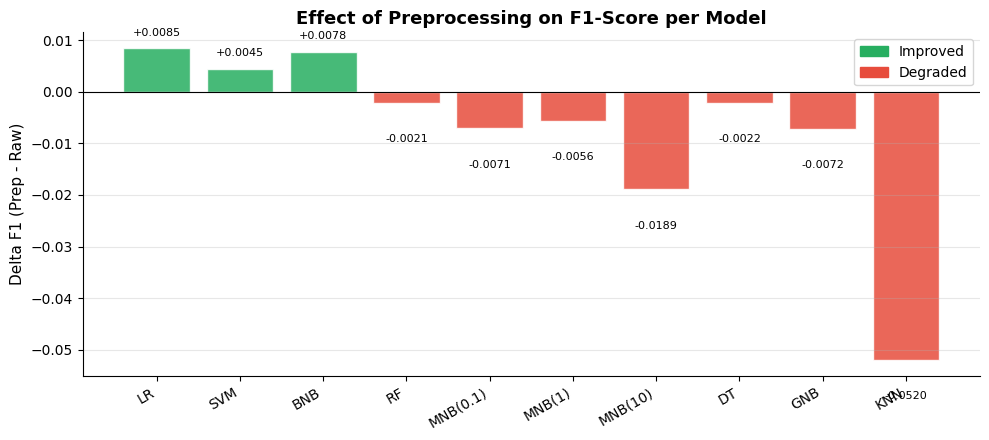

fig7.png saved.


In [24]:
delta_vals = tableF['Delta_F1'].tolist()
colors_d   = ['#27AE60' if d>=0 else '#E74C3C' for d in delta_vals]
fig, ax = plt.subplots(figsize=(10,4.5))
bars = ax.bar(x, delta_vals, color=colors_d, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, delta_vals):
    yp = bar.get_height()+0.002 if val>=0 else bar.get_height()-0.008
    ax.text(bar.get_x()+bar.get_width()/2, yp, f'{val:+.4f}',
            ha='center', va='bottom', fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(model_order_f, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Delta F1 (Prep - Raw)', fontsize=11)
ax.set_title('Effect of Preprocessing on F1-Score per Model', fontsize=13, fontweight='bold')
green_p = mpatches.Patch(color='#27AE60', label='Improved')
red_p   = mpatches.Patch(color='#E74C3C', label='Degraded')
ax.legend(handles=[green_p, red_p], fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig7.png saved.')

## 25. Figure 8 — Heatmap: All 4 Metrics × All Models, Preprocessed (fig8.png)

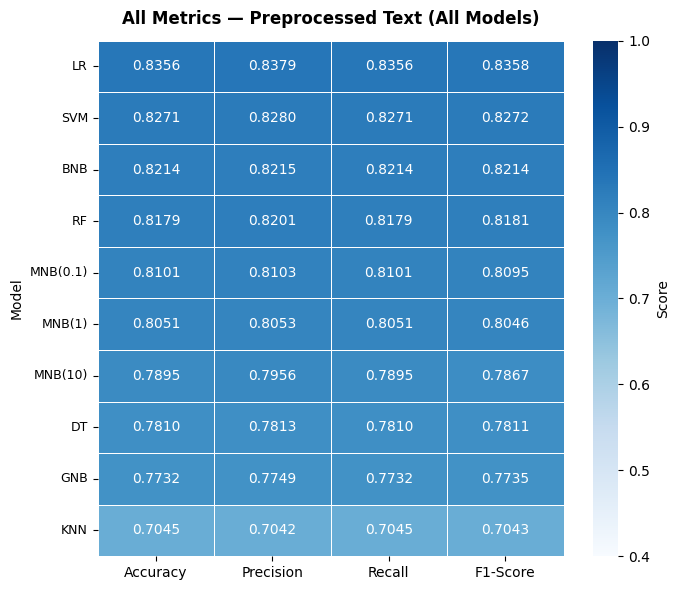

fig8.png saved.


In [25]:
hm_data = tableF.set_index('Model')[['Prep_Acc','Prep_Prec','Prep_Rec','Prep_F1']]
hm_data.columns = ['Accuracy','Precision','Recall','F1-Score']
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(hm_data, annot=True, fmt='.4f', cmap='Blues',
            vmin=0.4, vmax=1.0, linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label':'Score'})
ax.set_title('All Metrics — Preprocessed Text (All Models)',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig8.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig8.png saved.')

## 26. Figure 9 — Top 3 Models: Full Metric Comparison (fig9.png)

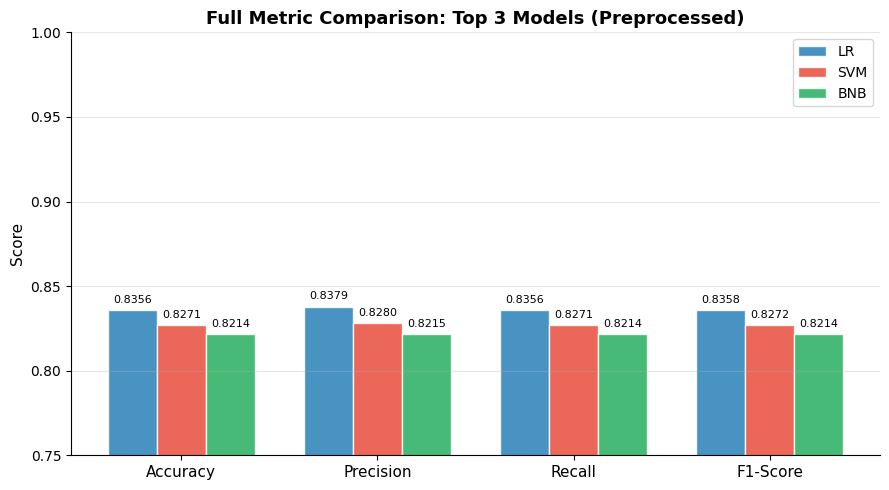

fig9.png saved.


In [26]:
top3    = tableF.head(3)
metrics = ['Prep_Acc','Prep_Prec','Prep_Rec','Prep_F1']
mlabs   = ['Accuracy','Precision','Recall','F1-Score']
x_m     = np.arange(len(mlabs))
width   = 0.25
c3      = ['#2980B9','#E74C3C','#27AE60']
fig, ax = plt.subplots(figsize=(9,5))
for i, (_, row) in enumerate(top3.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x_m+(i-1)*width, vals, width,
                  label=row['Model'], color=c3[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x_m); ax.set_xticklabels(mlabs, fontsize=11)
ax.set_ylabel('Score', fontsize=11); ax.set_ylim(0.75, 1.0)
ax.set_title('Full Metric Comparison: Top 3 Models (Preprocessed)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig9.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig9.png saved.')

## 27. Confusion Matrix — Best Model

Best model: LR
Best F1: 0.8358
              precision    recall  f1-score   support

Non-Hate (0)       0.80      0.86      0.83       655
    Hate (1)       0.87      0.81      0.84       756

    accuracy                           0.84      1411
   macro avg       0.84      0.84      0.84      1411
weighted avg       0.84      0.84      0.84      1411



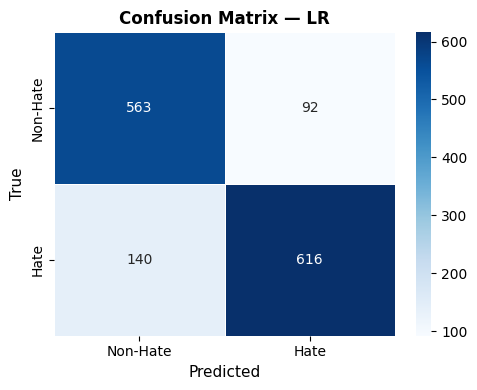

confusion_matrix.png saved.


In [27]:
# Re-run best model to get predictions
best_mname = tableF.iloc[0]['Model']
print(f'Best model: {best_mname}')

models     = get_models()
clf_b, pg_b = models[best_mname]
best_f1_b  = -1
best_pred_b = None

for vec_type in ['count','tfidf']:
    for ngram in [(1,1),(1,2),(1,3),(2,2),(3,3),(4,4),(5,5)]:
        for min_df in [1,2,5]:
            try:
                analyzer = 'char' if ngram[0]==ngram[1] and ngram[0]>=2 else 'word'
                # correct: word ngrams have range start=1, char ngrams have equal values
                if ngram in [(1,1),(1,2),(1,3)]:
                    analyzer = 'word'
                else:
                    analyzer = 'char'
                vec  = build_vec(vec_type, analyzer, ngram, min_df)
                X_tr = vec.fit_transform(X_prep_train)
                X_te = vec.transform(X_prep_test)
                clf_copy = copy.deepcopy(clf_b)
                if best_mname in DENSE_MODELS:
                    X_tr = X_tr.toarray(); X_te = X_te.toarray()
                if pg_b:
                    gs = GridSearchCV(clf_copy, pg_b, cv=3,
                                      scoring='f1_weighted', n_jobs=-1)
                    gs.fit(X_tr, y_train)
                    y_pred_b = gs.best_estimator_.predict(X_te)
                else:
                    clf_copy.fit(X_tr, y_train)
                    y_pred_b = clf_copy.predict(X_te)
                f1_b = f1_score(y_test, y_pred_b, average='weighted')
                if f1_b > best_f1_b:
                    best_f1_b  = f1_b
                    best_pred_b = y_pred_b
            except:
                continue

print(f'Best F1: {best_f1_b:.4f}')
print(classification_report(y_test, best_pred_b,
      target_names=['Non-Hate (0)','Hate (1)']))

cm = confusion_matrix(y_test, best_pred_b)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hate','Hate'],
            yticklabels=['Non-Hate','Hate'],
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_mname}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show(); print('confusion_matrix.png saved.')

## 28. Figure 10 — Error Analysis (fig10.png)

Total test samples : 1411
Total errors       : 232 (16.44%)
False Positives    : 92  (Non-hate predicted as Hate)
False Negatives    : 140  (Hate predicted as Non-hate)

--- Sample False Positives (5) ---
                                      text  true  predicted
                           porn star model     0          1
                       sundor fuatar brain     0          1
fura furi buja jaar kunbay kusa kusi soler     0          1
      tumarare bangla pam der tumra bujray     0          1
         tumra bura oijiray be biya kortay     0          1

--- Sample False Negatives (5) ---
                                         text  true  predicted
magna paiso sundor hizra oguray kailaw lutiya     1          0
                       bitree de bara failaic     1          0
               teng bhainga hate dhoraya dimu     1          0
                     viral link faa faa soler     1          0
                  moja tumio faiso eo faisoin     1          0


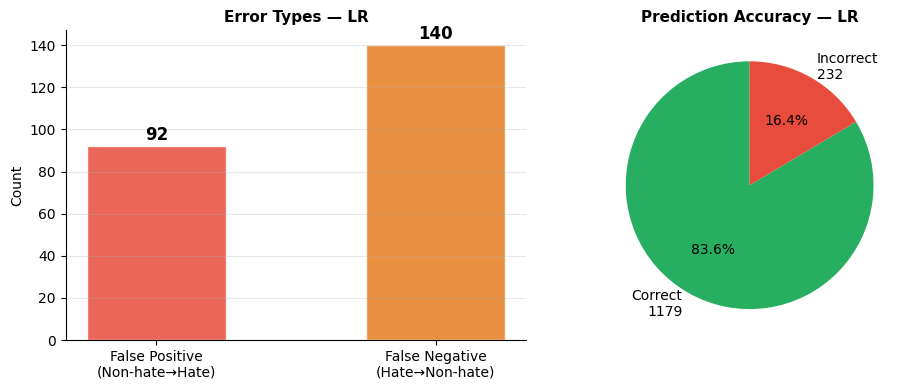

fig10.png saved.


In [28]:
error_df = pd.DataFrame({
    'text'     : X_prep_test,
    'true'     : y_test,
    'predicted': best_pred_b
})
error_df['correct'] = error_df['true'] == error_df['predicted']
errors = error_df[~error_df['correct']]
fp = errors[(errors.true==0) & (errors.predicted==1)]
fn = errors[(errors.true==1) & (errors.predicted==0)]

print(f'Total test samples : {len(error_df)}')
print(f'Total errors       : {len(errors)} ({len(errors)/len(error_df)*100:.2f}%)')
print(f'False Positives    : {len(fp)}  (Non-hate predicted as Hate)')
print(f'False Negatives    : {len(fn)}  (Hate predicted as Non-hate)')
print(f'\n--- Sample False Positives (5) ---')
print(fp[['text','true','predicted']].head(5).to_string(index=False))
print(f'\n--- Sample False Negatives (5) ---')
print(fn[['text','true','predicted']].head(5).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
# Left: FP vs FN
axes[0].bar(['False Positive\n(Non-hate→Hate)', 'False Negative\n(Hate→Non-hate)'],
            [len(fp), len(fn)],
            color=['#E74C3C','#E67E22'], alpha=0.85, edgecolor='white', width=0.5)
for i, v in enumerate([len(fp), len(fn)]):
    axes[0].text(i, v+1, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title(f'Error Types — {best_mname}', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
# Right: correct vs incorrect pie
axes[1].pie([len(error_df)-len(errors), len(errors)],
            labels=[f'Correct\n{len(error_df)-len(errors)}',
                    f'Incorrect\n{len(errors)}'],
            colors=['#27AE60','#E74C3C'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize':10})
axes[1].set_title(f'Prediction Accuracy — {best_mname}', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig10.png', dpi=300, bbox_inches='tight')
plt.show(); print('fig10.png saved.')

## 29. Final Summary

In [29]:
print('='*60)
print('FINAL SUMMARY')
print('='*60)
print(f'Dataset          : {total:,} samples')
print(f'  Hate (1)       : {hate_count:,} ({hate_count/total*100:.1f}%)')
print(f'  Non-hate (0)   : {nohate_count:,} ({nohate_count/total*100:.1f}%)')
print(f'Train / Test     : {len(X_raw_train)} / {len(X_raw_test)}')
print()
print(f'Best Model (Prep F1) : {tableF.iloc[0]["Model"]} — {tableF.iloc[0]["Prep_F1"]:.4f}')
print(f'2nd  Model (Prep F1) : {tableF.iloc[1]["Model"]} — {tableF.iloc[1]["Prep_F1"]:.4f}')
print(f'3rd  Model (Prep F1) : {tableF.iloc[2]["Model"]} — {tableF.iloc[2]["Prep_F1"]:.4f}')
print()
print('Output files saved to:', OUTPUT_DIR)
print('  Tables : tableA–tableF (.csv)')
print('  fig1   : Label distribution')
print('  fig2   : Accuracy raw vs prep')
print('  fig3   : F1 raw vs prep')
print('  fig4   : CV word n-gram accuracy trend')
print('  fig5   : TF-IDF word n-gram accuracy trend')
print('  fig6   : Char n-gram CV vs TF-IDF')
print('  fig7   : Delta F1 preprocessing effect')
print('  fig8   : Heatmap all metrics all models')
print('  fig9   : Top 3 models full metrics')
print('  fig10  : Error analysis')
print('  confusion_matrix.png')
print('='*60)

FINAL SUMMARY
Dataset          : 7,054 samples
  Hate (1)       : 3,781 (53.6%)
  Non-hate (0)   : 3,273 (46.4%)
Train / Test     : 5643 / 1411

Best Model (Prep F1) : LR — 0.8358
2nd  Model (Prep F1) : SVM — 0.8272
3rd  Model (Prep F1) : BNB — 0.8214

Output files saved to: /content/drive/MyDrive/SylHate/outputs
  Tables : tableA–tableF (.csv)
  fig1   : Label distribution
  fig2   : Accuracy raw vs prep
  fig3   : F1 raw vs prep
  fig4   : CV word n-gram accuracy trend
  fig5   : TF-IDF word n-gram accuracy trend
  fig6   : Char n-gram CV vs TF-IDF
  fig7   : Delta F1 preprocessing effect
  fig8   : Heatmap all metrics all models
  fig9   : Top 3 models full metrics
  fig10  : Error analysis
  confusion_matrix.png
